In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [61]:
# Load data
train_df = pd.read_csv(
    "/content/BT2024087_train_var1.csv"
)

test_df = pd.read_csv(
    "/content/BT2024087_test_var1.csv"
)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (1000, 7)
Test shape: (1000, 6)


In [62]:
# Separate features and target

feature_cols = [c for c in train_df.columns if c != "y"]

X = train_df[feature_cols].values.astype(float)
y = train_df["y"].values.astype(float)
X_test = test_df[feature_cols].values.astype(float)

print("Features:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

Features: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
X shape: (1000, 6)
y shape: (1000,)
X_test shape: (1000, 6)


In [63]:
# Create polynomial features
def make_polynomial_features(X_train, X_val, degree):
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    return X_train_poly, X_val_poly, poly

In [64]:
# Calculate Ridge weights
def calculate_ridge_weights(X, y, alpha):
    X_bias = np.column_stack(
        (np.ones(X.shape[0]), X)
    )

    n_features = X_bias.shape[1]

    I = np.eye(n_features)
    I[0, 0] = 0

    weights = np.linalg.solve(
        X_bias.T @ X_bias + alpha * I,
        X_bias.T @ y
    )

    return weights

In [65]:
# Make predictions
def predict(X, weights):
    X_bias = np.column_stack(
        (np.ones(X.shape[0]), X)
    )

    return X_bias @ weights

In [66]:
# Calculate MSE
def calculate_mse(y, y_pred):
    return np.mean(
        (y - y_pred) ** 2
    )


# Calculate R2
def calculate_r2(y, y_pred):
    ss_res = np.sum(
        (y - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y - np.mean(y)) ** 2
    )

    return 1 - (ss_res / ss_tot)

In [67]:
# Standardize features
class StandardScaler:

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)

        self.std_[self.std_ == 0] = 1.0

        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [68]:
# Setup 5-fold cross validation
class KFold:

    def __init__(
        self,
        n_splits=5,
        shuffle=True,
        seed=42
    ):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.seed = seed

    def split(self, n_samples):

        indices = np.arange(n_samples)

        if self.shuffle:
            np.random.RandomState(
                self.seed
            ).shuffle(indices)

        folds = np.array_split(
            indices,
            self.n_splits
        )

        for i in range(self.n_splits):

            val_index = folds[i]

            train_index = np.concatenate(
                [
                    folds[j]
                    for j in range(self.n_splits)
                    if j != i
                ]
            )

            yield train_index, val_index

In [69]:
# Setup cross validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    seed=42
)

# Alpha values to test
alphas = np.logspace(
    -4,
    4,
    9
)

# Test degrees from 1 to 10
results = []

In [70]:
for degree in range(1, 11):

    best_degree_mse = float("inf")
    best_degree_r2 = None
    best_degree_alpha = None

    # Try different alpha values
    for alpha in alphas:

        mse_values = []
        r2_values = []

        # Perform 5-fold cross validation
        for train_index, val_index in kf.split(len(X)):

            X_train = X[train_index]
            y_train = y[train_index]

            X_val = X[val_index]
            y_val = y[val_index]

            # Polynomial features
            X_train_poly, X_val_poly, poly = (
                make_polynomial_features(
                    X_train,
                    X_val,
                    degree
                )
            )

            # Standardize polynomial features
            scaler = StandardScaler()

            X_train_poly = scaler.fit_transform(
                X_train_poly
            )

            X_val_poly = scaler.transform(
                X_val_poly
            )

            # Ridge regression
            weights = calculate_ridge_weights(
                X_train_poly,
                y_train,
                alpha
            )

            # Validation prediction
            y_val_pred = predict(
                X_val_poly,
                weights
            )

            # Metrics
            fold_mse = calculate_mse(
                y_val,
                y_val_pred
            )

            fold_r2 = calculate_r2(
                y_val,
                y_val_pred
            )

            mse_values.append(fold_mse)
            r2_values.append(fold_r2)

        # Average CV metrics
        mean_mse = np.mean(mse_values)
        mean_r2 = np.mean(r2_values)

        # Keep best alpha for this degree
        if mean_mse < best_degree_mse:

            best_degree_mse = mean_mse
            best_degree_r2 = mean_r2
            best_degree_alpha = alpha

    # Store result
    results.append(
        (
            degree,
            best_degree_mse,
            best_degree_r2,
            best_degree_alpha
        )
    )

    print(
        f"Degree {degree:2d} | "
        f"CV MSE: {best_degree_mse:.6f} | "
        f"R2: {best_degree_r2:.6f} | "
        f"Alpha: {best_degree_alpha}"
    )

Degree  1 | CV MSE: 9.203174 | R2: 0.133537 | Alpha: 10.0
Degree  2 | CV MSE: 3.124521 | R2: 0.705318 | Alpha: 10.0
Degree  3 | CV MSE: 0.963832 | R2: 0.909022 | Alpha: 10.0
Degree  4 | CV MSE: 0.754633 | R2: 0.929006 | Alpha: 10.0
Degree  5 | CV MSE: 0.590672 | R2: 0.944367 | Alpha: 10.0
Degree  6 | CV MSE: 0.712204 | R2: 0.932781 | Alpha: 100.0
Degree  7 | CV MSE: 0.694086 | R2: 0.934460 | Alpha: 100.0
Degree  8 | CV MSE: 0.851247 | R2: 0.919537 | Alpha: 100.0
Degree  9 | CV MSE: 0.907043 | R2: 0.914258 | Alpha: 100.0
Degree 10 | CV MSE: 1.146781 | R2: 0.891526 | Alpha: 100.0


In [71]:
# Store CV results
degrees = [r[0] for r in results]
cv_mse = [r[1] for r in results]
cv_r2 = [r[2] for r in results]

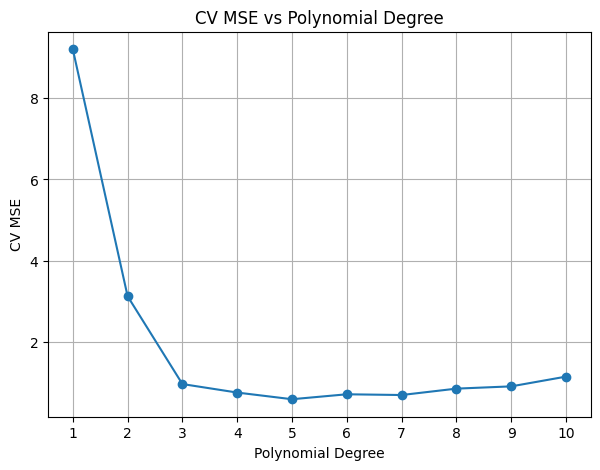

In [72]:
# CV MSE graph
plt.figure(figsize=(7, 5))

plt.plot(
    degrees,
    cv_mse,
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("CV MSE")
plt.title("CV MSE vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)

plt.show()

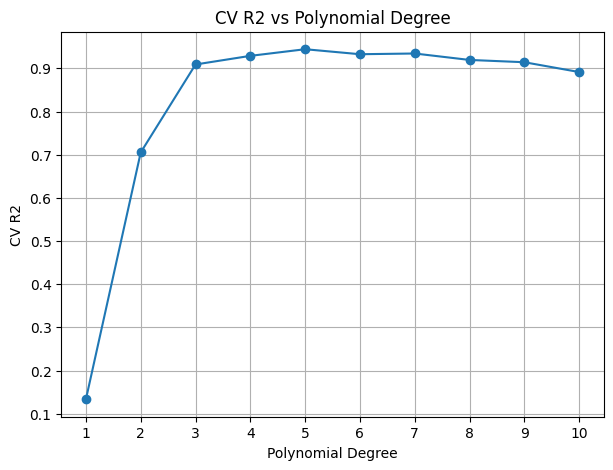

In [73]:
# CV R2 graph
plt.figure(figsize=(7, 5))

plt.plot(
    degrees,
    cv_r2,
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("CV R2")
plt.title("CV R2 vs Polynomial Degree")
plt.xticks(degrees)
plt.grid(True)

plt.show()

In [74]:
# Select best degree and alpha
best_degree, best_mse, best_r2, best_alpha = min(
    results,
    key=lambda x: x[1]
)

print("Best Degree:", best_degree)
print("Best CV MSE:", best_mse)
print("Best CV R2:", best_r2)
print("Best Alpha:", best_alpha)

Best Degree: 5
Best CV MSE: 0.5906715553722821
Best CV R2: 0.944367203414252
Best Alpha: 10.0


In [75]:
# Create polynomial features using all training data
poly = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)

# Standardize polynomial features
scaler = StandardScaler()

X_poly = scaler.fit_transform(X_poly)
X_test_poly = scaler.transform(X_test_poly)

# Calculate final Ridge weights
weights = calculate_ridge_weights(
    X_poly,
    y,
    best_alpha
)

# Training prediction
y_train_pred = predict(
    X_poly,
    weights
)

# Training performance
train_mse = calculate_mse(
    y,
    y_train_pred
)

train_r2 = calculate_r2(
    y,
    y_train_pred
)

print("Final Training MSE:", train_mse)
print("Final Training R2:", train_r2)

Final Training MSE: 0.20384552115280252
Final Training R2: 0.9808663361946629


In [76]:
# Predict test data
y_test_pred = predict(
    X_test_poly,
    weights
)

# Create prediction dataframe with only the predicted y values
submission = pd.DataFrame({"y": y_test_pred})

print(submission.head())

# Save to CSV (no index column)
submission.to_csv("BT2024087_pred_var1.csv", index=False)
print("Predictions saved to:")
print("/content/BT2024087_pred_var1.csv")

          y
0 -3.795592
1  0.761623
2  0.847146
3  0.684841
4  1.955397
Predictions saved to:
/content/BT2024087_pred_var1.csv
